In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
df = pd.read_csv('Data.csv')
print(df)

    feature1  feature2     target
0   3.745401  0.157146  12.063147
1   9.507143  3.182052  40.103612
2   7.319939  1.571780  29.349493
3   5.986585  2.542853  24.610051
4   1.560186  4.537832  18.267866
..       ...       ...        ...
95  4.937956  1.746048  19.468283
96  5.227328  3.629778  29.086114
97  4.275410  4.485551  24.745002
98  0.254191  4.435432   7.238766
99  1.078914  3.899378  13.410679

[100 rows x 3 columns]


In [17]:
#define targets and features
X = df[['feature1', 'feature2']] 
y = df['target']

#splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

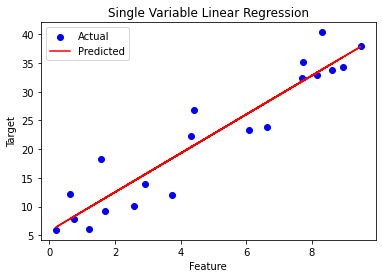

In [25]:
#SINGLE VARIABLE REGRESSION

#selecting a feature
X_single = X[['feature1']]

#splitting the data
X_single_train, X_single_test, y_train_single, y_test_single = train_test_split(X_single, y, test_size=0.2, random_state=42)

#linear regression
lin_reg_single = LinearRegression()
lin_reg_single.fit(X_single_train, y_train_single)

#predictions
y_pred_single = lin_reg_single.predict(X_single_test)
MSE_single = mean_squared_error(y_test_single, y_pred_single)    #MSE
R2_single = r2_score(y_test_single, y_pred_single)               #R2

#visualization
plt.scatter(X_single_test, y_test_single, color='blue', label='Actual')
plt.plot(X_single_test, y_pred_single, color='red', label='Predicted')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Single Variable Linear Regression')
plt.legend()
plt.show()

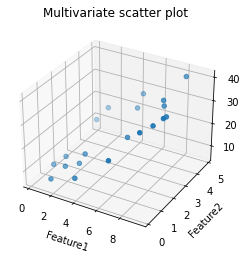

In [31]:
#MULTI VARIABLE REGRESSION

#multi variable regression
lin_reg_multi = LinearRegression()
lin_reg_multi.fit(X_train, y_train)

#predictions
y_pred_multi = lin_reg_multi.predict(X_test)

MSE_single = mean_squared_error(y_test, y_pred_multi)    #MSE
R2_single = r2_score(y_test, y_pred_multi)               #R2

fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

ax.scatter(X_test['feature1'], X_test['feature2'], y_test)
ax.set_xlabel("Feature1")
ax.set_ylabel("Feature2")
ax.set_zlabel("Target")

ax.set_title("Multivariate scatter plot")

plt.show()

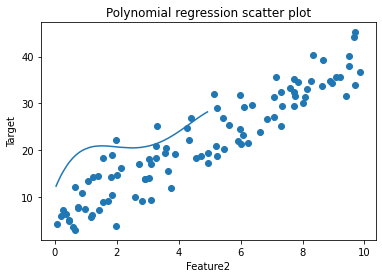

In [36]:
#POLYNOMIAL REGRESSION

poly = PolynomialFeatures(degree=4)
X_poly = poly.fit_transform(X[['feature2']])

#splitting data
X_poly_train, X_poly_test, y_train_poly, y_test_poly = train_test_split(X_poly, y, test_size=0.2, random_state=42)

#transform
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly_train, y_train_poly)

#predictions
y_pred_poly = lin_reg_poly.predict(X_poly_test)

MSE_single = mean_squared_error(y_test_poly, y_pred_poly)    #MSE
R2_single = r2_score(y_test_poly, y_pred_poly)               #R2

X_sorted = df[['feature2']].sort_values(by='feature2')
X_sorted_poly = poly.transform(X_sorted)
Y_sorted_pred = lin_reg_poly.predict(X_sorted_poly)

plt.scatter(df[['feature1']], y)
plt.plot(X_sorted, Y_sorted_pred)
plt.xlabel("Feature2")
plt.ylabel("Target")
plt.title("Polynomial regression scatter plot")

plt.show()